
---
## TEAM MEMBERS
* Gomez Serrato Alejandro 
* Quinche Juan Pablo 
* Quintero Diaz Juan Jóse 
---
# Part 1: Data Loading & Preprocessing


1. Load `student_data.csv`.
2. Perform basic Exploratory Data Analysis (EDA). Plot the distribution of `critical_temp`.
3. Check for missing values or extreme anomalies. Be very careful: remove data or if you impute it, justify strongly. 
5. Split this training data into your own local train/test sets (e.g., 80/20) so you can evaluate your models.
6. **Feature Scaling:** Apply appropriate scaling. *Hint: Think carefully about why scaling is absolutely strictly necessary for both Regularized Linear Models and Neural Networks.*

## 1.1) Data loading

In [19]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import functions as f

path = './data/student_data.csv'
df = pd.read_csv(path)
print("the size of the dataset is:", np.size(df))
df.head()
print("amount of columns:", df.columns.size)

the size of the dataset is: 1462860
amount of columns: 86


## 1.2) EDA for cf


--- Statistical Summary of cfinal ---

Skewness: 0.8564850677436356
Kurtosis: -0.5362429567171461


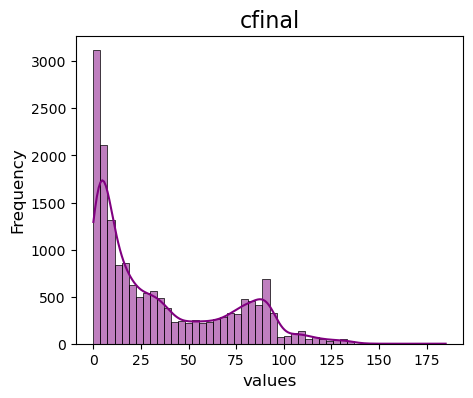

In [20]:
column = 'cfinal'
f.eda_info(df[column],column)

## 1.3) Missing values  and data Cleaning

amount of null values in the dataset: 1288
null values per column:
eon       14
amm       10
mwma      12
amg       14
wagm      17
          ..
msqv      18
ril       18
ped       12
deu        8
cfinal    17
Length: 86, dtype: int64


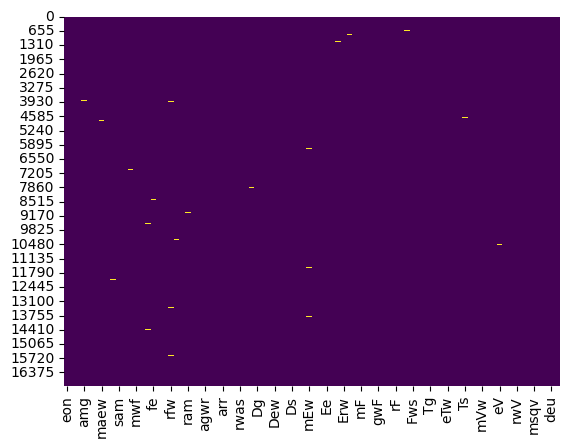

columns:  86
columns:  86


c:\Users\alejo\Desktop\capstone_project\functions.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


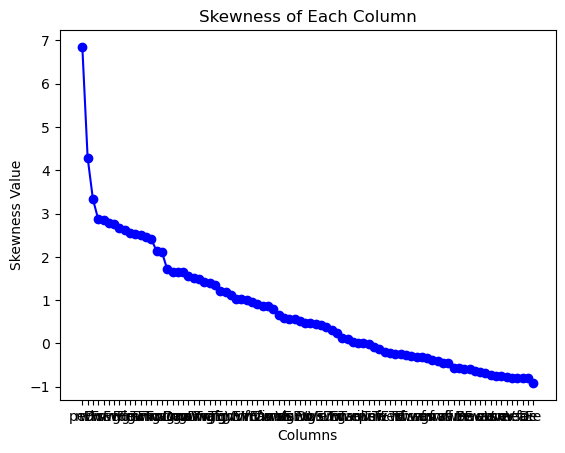

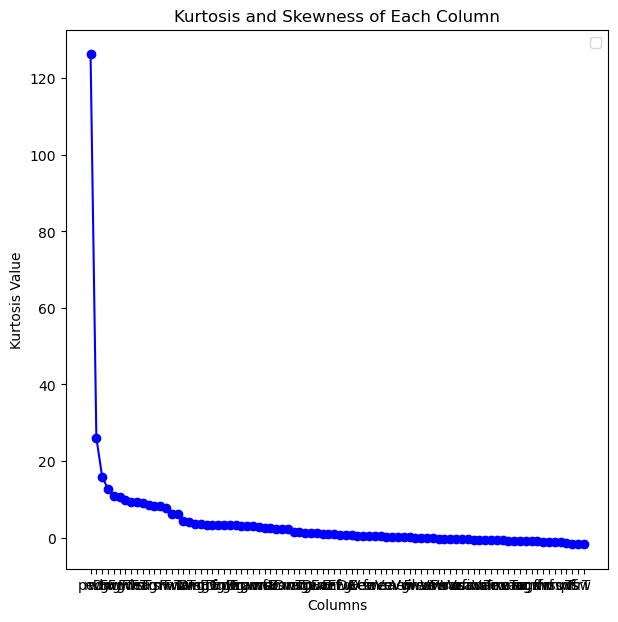

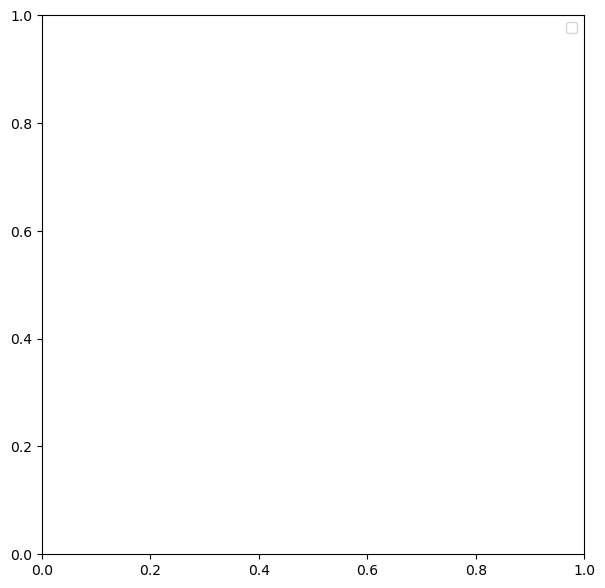

In [37]:

print("amount of null values in the dataset:", df.isna().sum().sum())
print("null values per column:")
print(df.isna().sum(axis=0))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()
kurtosis = df.kurtosis(axis=0)
skewness = df.skew(axis=0)
sk_sort, ku_sort = f.sort_values(skewness, kurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column', 'kurtosis']
f.plot_values(sk_sort.index, sk_sort.values, sk_text)
f.plot_values(ku_sort.index, ku_sort.values, ku_text)
#f.total_eda_info(df)
#f.IQR_outliers(df)


Classifying with kurtosis and skewness 

In [38]:

meso_kt, lepto_kt, platy_kt = f.classify_kurtosis(ku_sort,epsilon=0.1)
##Skewness classification
epsilon = 0.1
print("Meso-Kurtosis Columns skewness:")
left_sk_meso, middle_sk_meso, right_sk_meso = f.classify_skewness(meso_kt, epsilon)
print(" ")
print("Lepto-Kurtosis Columns skewness:")
left_sk_lepto, middle_sk_lepto, right_sk_lepto = f.classify_skewness(lepto_kt, epsilon)
print(" ")
print("Platy-Kurtosis Columns skewness:")
left_sk_platy, middle_sk_platy, right_sk_platy = f.classify_skewness(platy_kt, epsilon)



Mesokurtic columns:
 5 columns
Leptokurtic columns:
 53 columns
Platykurtic columns:
 28 columns
Meso-Kurtosis Columns skewness:
Left-skewed columns:
 5 columns
Right-skewed columns:
 5 columns
Approximately symmetric columns:
 5 columns
 
Lepto-Kurtosis Columns skewness:
Left-skewed columns:
 53 columns
Right-skewed columns:
 53 columns
Approximately symmetric columns:
 53 columns
 
Platy-Kurtosis Columns skewness:
Left-skewed columns:
 28 columns
Right-skewed columns:
 28 columns
Approximately symmetric columns:
 28 columns


In [39]:
print("Meso-Kurtosis Columns:")
print(meso_kt)

Meso-Kurtosis Columns:
             0
eVw   0.065858
eF    0.036338
ril   0.008819
gwV  -0.054869
wear -0.094710


* platy_kurtosis(Mean or min/max) is left skewed wich means we can use the median 
* lepto_kurtosis(Median) is Right skewed wich means we can use the median
* Meso_kurtosis(Mean) is symmetric wich means we can use the mean


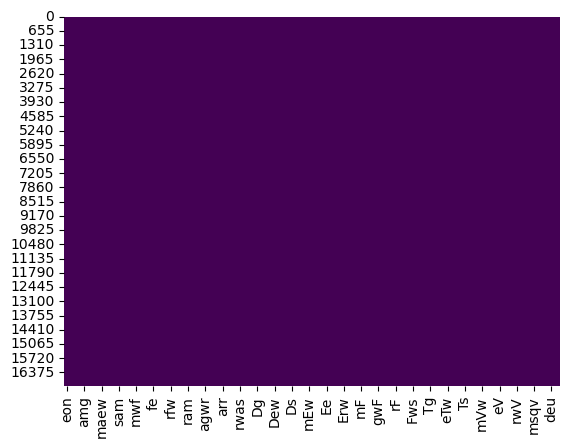

columns:  86
columns:  86


c:\Users\alejo\Desktop\capstone_project\functions.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


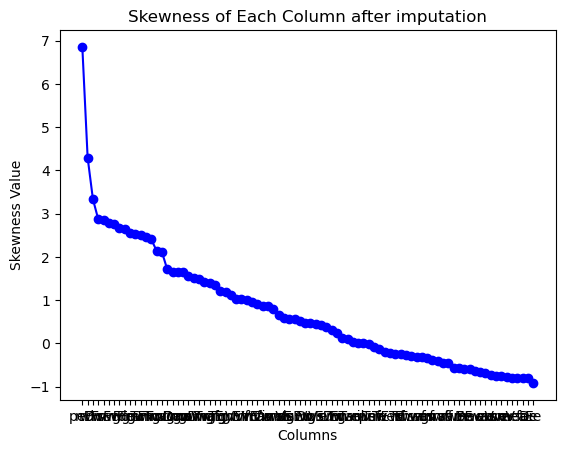

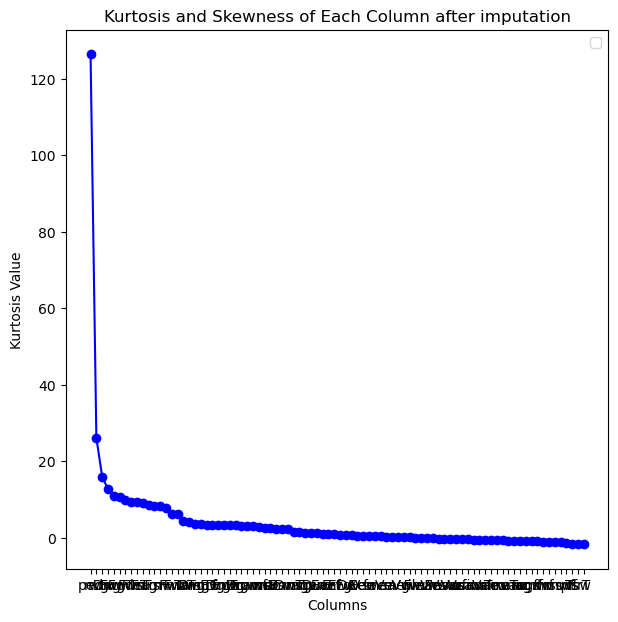

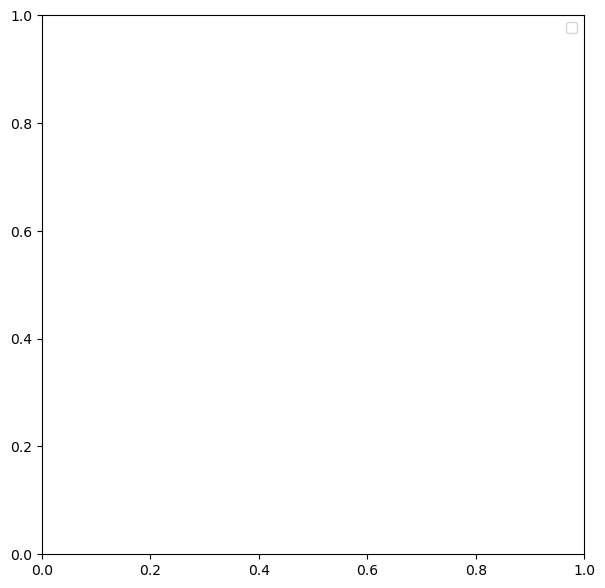

In [36]:
dvalues = df.copy()
dvalues = f.median_imputation(dvalues, meso_kt.index)
dvalues = f.median_imputation(dvalues, lepto_kt.index)
dvalues = f.mean_imputation(dvalues, platy_kt.index)
dvalues.isna().sum()
sns.heatmap(dvalues.isnull(), cbar=False, cmap='viridis')
plt.show()
dkurtosis = dvalues.kurtosis(axis=0)
dskewness = dvalues.skew(axis=0)
dsk_sort, dku_sort = f.sort_values(dskewness, dkurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column after imputation', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column after imputation', 'kurtosis']
f.plot_values(dsk_sort.index, dsk_sort.values, sk_text)
f.plot_values(dku_sort.index, dku_sort.values, ku_text)



--- Statistical Summary of ped ---

Skewness: 6.852915400913597
Kurtosis: 126.38996414859876


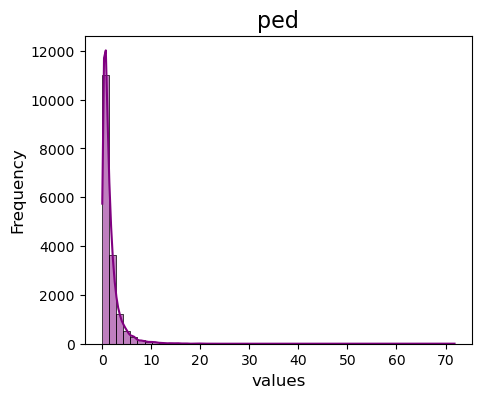

In [25]:
f.eda_info(dvalues['ped'],"ped")
#dvalues.drop(columns=['ped'], inplace=True)

## 1.4)Train test split


After correlation filtering:
Features remaining: 81
Training set shape: (13608, 81)
Testing set shape:  (3402, 81)


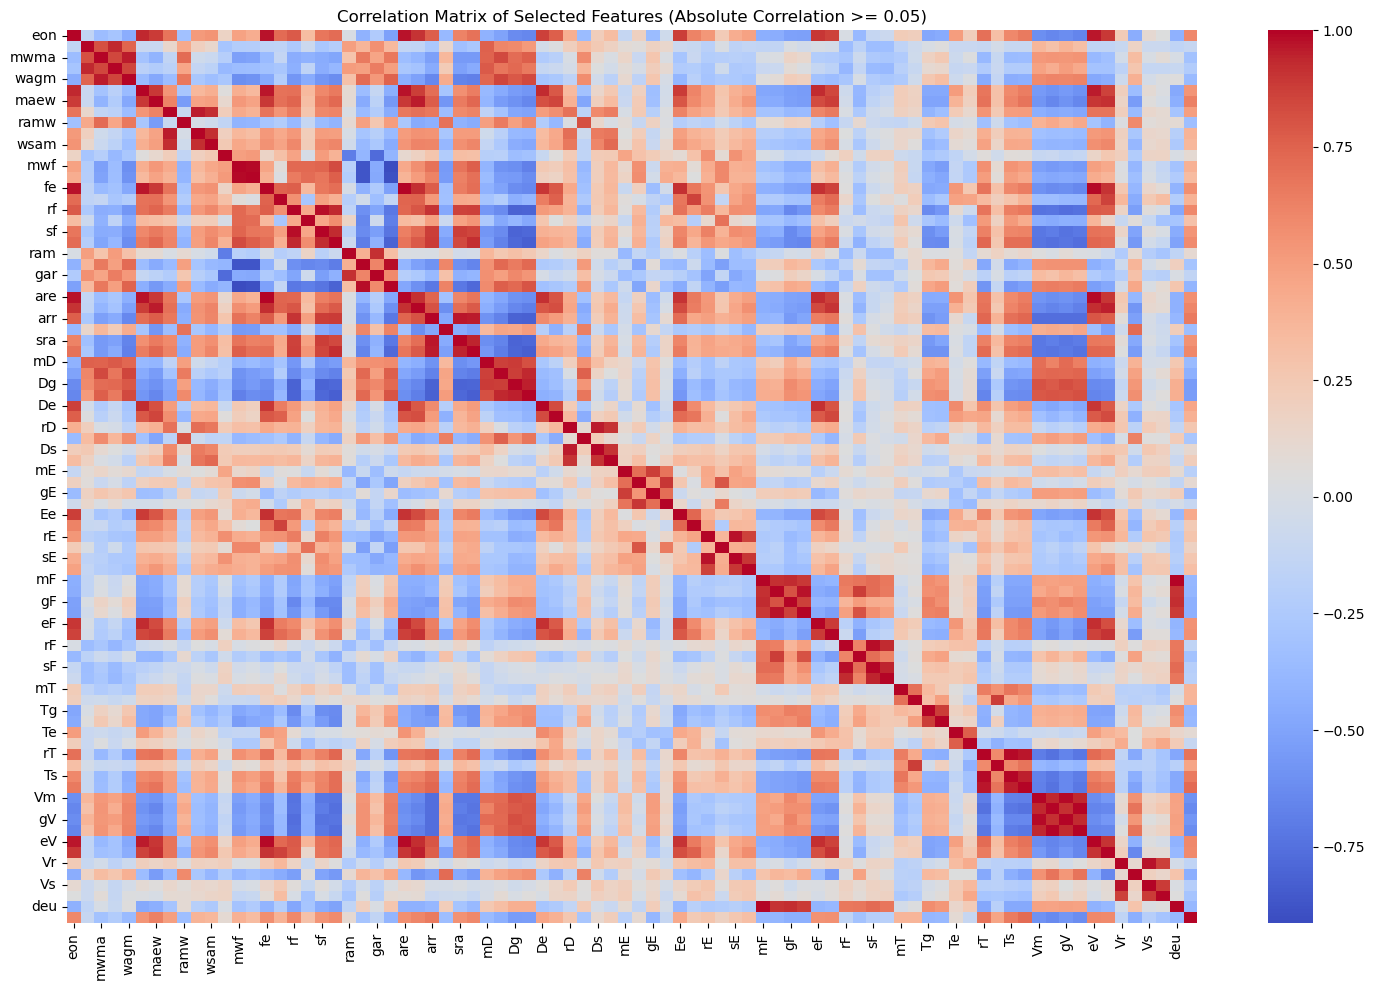

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#Alternative iterative imputation
#X_imputed,Y = f.iterative_imputation(dvalues, 'cfinal')
#X_train,X_test,Y_train,Y_test = train_test_split(X_imputed,Y, test_size=0.2, random_state=42)

X = dvalues.drop('cfinal', axis=1)
Y = dvalues['cfinal']
corr_matrix_full = dvalues.corr()
# Volvemos a hacer el split local para asegurar consistencia
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Filtrado por correlación estricto (utilizando solo el Train Set)
train_combined = X_train.copy()
train_combined['cfinal'] = Y_train
target_corr = train_combined.corr()['cfinal'].drop('cfinal')
threshold = 0.05
features_to_use = list(target_corr[abs(target_corr) >= threshold].index)
#Usamos las dimensiones filtradas para crear los nuevos conjuntos de entrenamiento y prueba
X_train_filtered = X_train[features_to_use]
X_test_filtered = X_test[features_to_use]

print(f"\nAfter correlation filtering:")
print(f"Features remaining: {X_train_filtered.shape[1]}")
print(f"Training set shape: {X_train_filtered.shape}")
print(f"Testing set shape:  {X_test_filtered.shape}")

plt.figure(figsize=(15, 10))
keep_cols = list(features_to_use) + ['cfinal']
sns.heatmap(corr_matrix_full.loc[keep_cols, keep_cols], 
            annot=False, 
            cmap='coolwarm', 
            fmt=".2f")
plt.title(f'Correlation Matrix of Selected Features (Absolute Correlation >= {threshold})')
plt.tight_layout() 
plt.show()

## 1.5) Scaling the features

In [27]:
from sklearn.preprocessing import StandardScaler
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_filtered)
X_test_scaled = scaler_final.transform(X_test_filtered)



# Part 2: Conceptual Questions & Model Selection

**Answer the following questions below:**
1. Why is this specific problem framed as a **Regression** task?
2. If a colleague suggested using **Logistic Regression** for this task, how would you explain to them mathematically and conceptually why that is the wrong choice?

Because we are trying to predict the behaviour of cfinal, wich we can consider as a continuous variable that depends on a linear combination of the other features.
Wich means that a linear regression model is appropriate for this task, as it can capture the linear relationships between the features and the target variable.
Furthermore cfinal is a normal distribution with kurtosis and skewness values close to 0, which indicates that it is a good candidate for linear regression.
2.Logistic regression is not suitable for this task because it is designed for classification problems, where the target variable is categorical. In contrast, linear regression is specifically designed for regression problems, where the target variable is continuous, making it the appropriate choice for predicting the final grade of the students.
In the case of the linear regression we have a continous set of values as.
\begin{equation*}
\hat{y} = \beta_{0} + \beta_{1}x_{1} +...+\beta_{n}x_{n}
\end{equation*}
 And in Logistic regression we use the sigmoid function wich maps the values between 0 and 1. 
\begin{equation*}
P(y=1|X) = \frac{1}{1+ e^{-( \beta_{0} + \beta_{1}x_{1} +...+\beta_{n}x_{n})}}
\end{equation*}

* When z is large and positive $e^{-z}$ approaches 0, so $\sigma{(z)}$ approaches 1.
* When z is large and negative  $e^{-z}$ becomes very large, so $\sigma{(z)}$ approaches 0.
* When z = 0, $e^0 = 1$, so $\sigma{(z)} = 0.5 $


# Part 3: Linear Regression & Regularization
1. **Unregularized Linear Regression:** Train a standard Ordinary Least Squares (OLS) Linear Regression model. Record its performance (RMSE, MAE, and $R^2$) on your local test set.
2. Analyze the fullfilment of the linear regression model assumptions. 
3. **Regularization (Ridge & Lasso):** 
   * Train a Ridge (L2) and a Lasso (L1) regression model. 
   * Use $k$-fold cross-validation to find the optimal regularization hyperparameters ($\alpha$).
4. **Reflection:** Print the top 5 largest coefficients from your unregularized model and your Ridge model. How drastically did they change? 
5. **Feature Selection:** Did your Lasso model drop any features (set their coefficients to exactly zero)? Look specifically at `lattice_refraction_index` and `mean_quantum_spin_variance`. What does their coefficient in the Lasso model tell you about their physical relevance to superconductivity?
6. **Include your best linear model weights in the submission using `joblib`**

In [28]:
import numpy as np
import pandas as pd
import functions as f
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
print("--- 1. OLS Linear Regression ---")
u_model = LinearRegression()
u_model.fit(X_train_scaled, Y_train)
u_preds = u_model.predict(X_test_scaled)

# Cálculo de Métricas solicitadas
ols_rmse, ols_mae, ols_r2 = f.evaluate_model(u_model, X_test_scaled, Y_test, "Unregularized Linear Regression")



--- 1. OLS Linear Regression ---
Unregularized Linear Regression RMSE: 17.763
Unregularized Linear Regression MAE:  13.572
Unregularized Linear Regression R^2:  0.731



Checking for Linearity (Visual Check)...


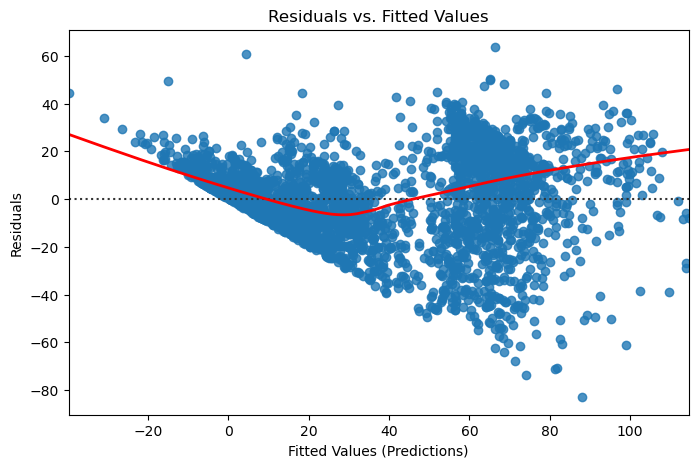

Checking for Independence of Residuals (Durbin-Watson Test)...
Durbin-Watson statistic: 1.95
Result: No significant autocorrelation (Good).


Checking for Homoscedasticity (Breusch-Pagan Test)...
Breusch-Pagan Test p-value: 0.0000
Result: Evidence of heteroscedasticity found (Bad).


Checking for Normality of Residuals (Q-Q Plot and Jarque-Bera)...


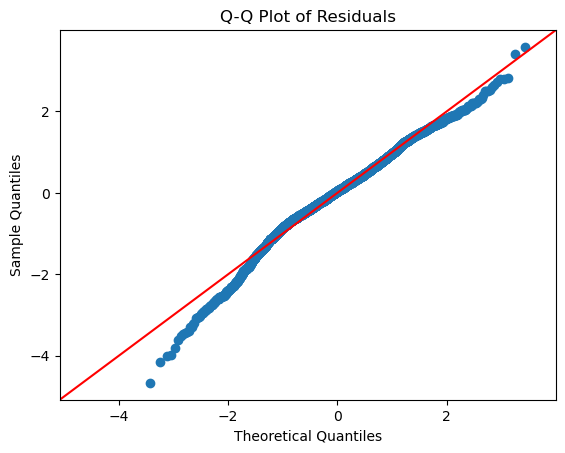

Jarque-Bera test probability (p-value): 0.0000
Result: Residuals may not be normally distributed (Bad).


Checking for Multicollinearity (VIF)...
    feature         VIF
0         0   65.580351
1         1  294.667902
2         2  601.350297
3         3  323.706673
4         4  632.513636
..      ...         ...
76       76   49.043391
77       77   20.136953
78       78   55.103922
79       79   16.229262
80       80  536.111141

[81 rows x 2 columns]

Result: Potential multicollinearity detected (Bad).




In [29]:
f.tests_check(u_model, X_test_scaled, Y_test)

### Ridge and Lasso

In [30]:

# Definimos una grilla logarítmica de alphas para buscar el óptimo
alphas_grid = np.logspace(-4, 4, 100)
# RidgeCV y LassoCV hacen la validación cruzada k-fold internamente
r_model = RidgeCV(alphas=alphas_grid, cv=5)
r_model.fit(X_train_scaled, Y_train)

l_model = LassoCV(alphas=alphas_grid, cv=5, max_iter=10000) # max_iter alto para convergencia
l_model.fit(X_train_scaled, Y_train)

print(f"Optimal Ridge alpha: {r_model.alpha_:.4f}")
print(f"Optimal Lasso alpha: {l_model.alpha_:.4f}\n")

Optimal Ridge alpha: 3.3516
Optimal Lasso alpha: 0.0020



In [31]:
r_mse, r_mae, r_r2 = f.evaluate_model(r_model, X_test_scaled, Y_test, "Ridge Regression")
l_mse, l_mae, l_r2 = f.evaluate_model(l_model, X_test_scaled, Y_test, "Lasso Regression")
#f.check_regularized_residuals(r_model, X_test_scaled, Y_test, "Ridge Regression")
#f.check_regularized_residuals(l_model, X_test_scaled, Y_test, "Lasso Regression")

Ridge Regression RMSE: 17.745
Ridge Regression MAE:  13.575
Ridge Regression R^2:  0.732

Lasso Regression RMSE: 17.760
Lasso Regression MAE:  13.571
Lasso Regression R^2:  0.731



Top 5 Coeficientes

In [32]:

print("--- 4. Reflection: Coefficient Comparison ---")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_filtered.columns) # Convertir a DataFrame para obtener nombres de columnas
features = X_train_scaled_df.columns # Asegúrate de que X_train_scaled sea un DataFrame, si es numpy usa tus feature_names

# Unir coeficientes en un DataFrame para compararlos
coef_df = pd.DataFrame({
    'Feature': features,
    'OLS_Coef': u_model.coef_,
    'Ridge_Coef': r_model.coef_,
    'Lasso_Coef': l_model.coef_
})


coef_df['OLS_abs'] = coef_df['OLS_Coef'].abs()
coef_df['ridge_abs'] = coef_df['Ridge_Coef'].abs()
coef_df['lasso_abs'] = coef_df['Lasso_Coef'].abs()
top_5_ols = coef_df.sort_values(by='OLS_abs', ascending=False).head(5)
top_5_ridge = coef_df.sort_values(by='ridge_abs', ascending=False).head(5)
top_5_lasso = coef_df.sort_values(by='lasso_abs', ascending=False).head(5)

print("Top 5 largest coefficients (Unregularized OLS):")
print(top_5_ols[['Feature', 'OLS_Coef']])

print("Top 5 largest coefficients (Ridge):")
print(top_5_ridge[['Feature', 'Ridge_Coef']])

print("Top 5 largest coefficients (Lasso):")
print(top_5_lasso[['Feature', 'Lasso_Coef']])



--- 4. Reflection: Coefficient Comparison ---
Top 5 largest coefficients (Unregularized OLS):
   Feature   OLS_Coef
21    rwam  33.228655
23    agwr -28.328181
48      sE  22.123160
61     Twm  21.709403
28     sra -19.071447
Top 5 largest coefficients (Ridge):
   Feature  Ridge_Coef
21    rwam   27.444320
48      sE   21.478280
23    agwr  -21.472746
61     Twm   20.939323
28     sra  -18.968690
Top 5 largest coefficients (Lasso):
   Feature  Lasso_Coef
21    rwam   31.895097
23    agwr  -26.827250
48      sE   21.836721
61     Twm   21.278119
28     sra  -18.609286


In [33]:
print("--- 5. Feature Selection (Lasso) ---")
dropped_features = coef_df[coef_df['Lasso_Coef'] == 0]['Feature'].tolist()
print(f"Lasso dropped {len(dropped_features)} features.")
for feature in ['ril', 'msqv']:
    if feature in coef_df['Feature'].values:
        val = coef_df.loc[coef_df['Feature'] == feature, 'Lasso_Coef'].values[0]
        if val == 0:
            print(f"-> {feature} fue eliminada (coef = 0). Físicamente, esto sugiere que no tiene poder predictivo o es redundante para predecir la temperatura crítica.")
        else:
            print(f"-> {feature} se mantuvo con un coeficiente de {val:.4f}.")

# ==========================================
# 6. Save Best Linear Model
# ==========================================
# Asumiendo que el mejor fue Ridge basándonos en tu prueba preliminar
best_model = r_model
joblib.dump(best_model, 'best_linear_model.pkl')
print("\nModelo guardado exitosamente como 'best_linear_model.pkl'")
#model testing


--- 5. Feature Selection (Lasso) ---
Lasso dropped 1 features.

Modelo guardado exitosamente como 'best_linear_model.pkl'


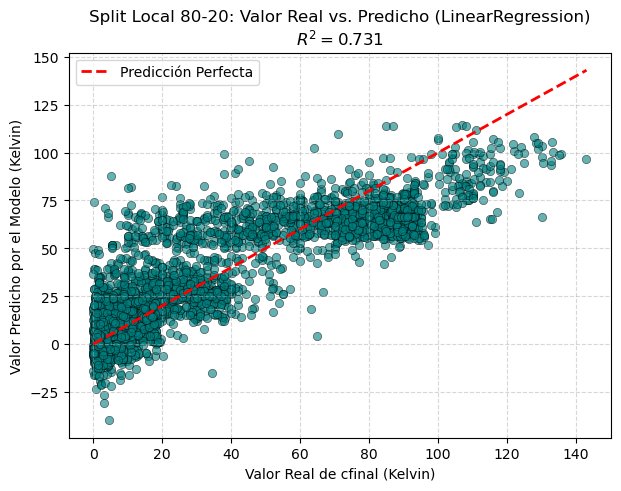

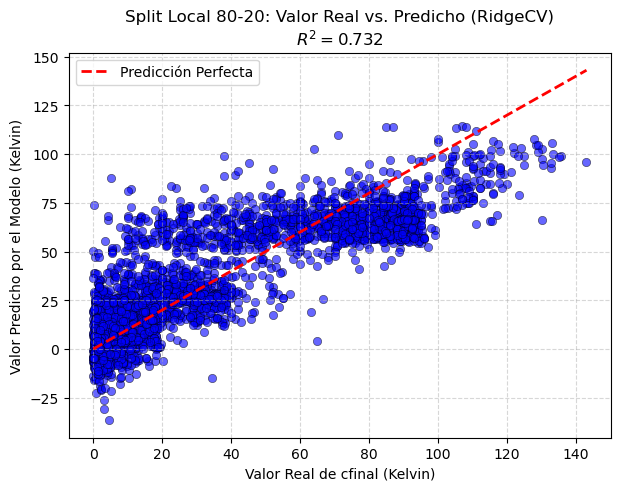

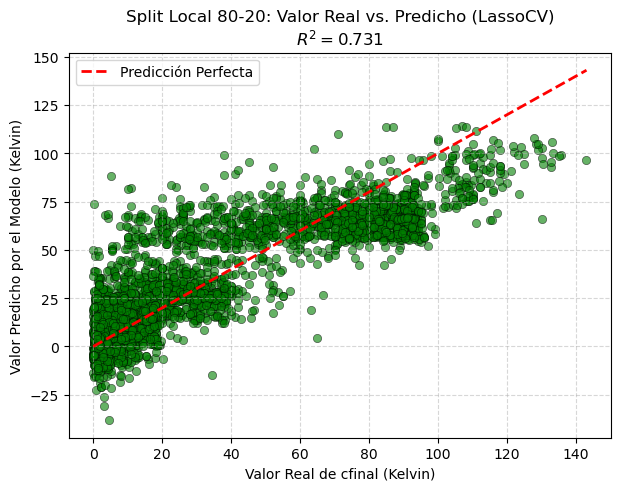

--- RENDIMIENTO EN EL SPLIT LOCAL (80-20) ---


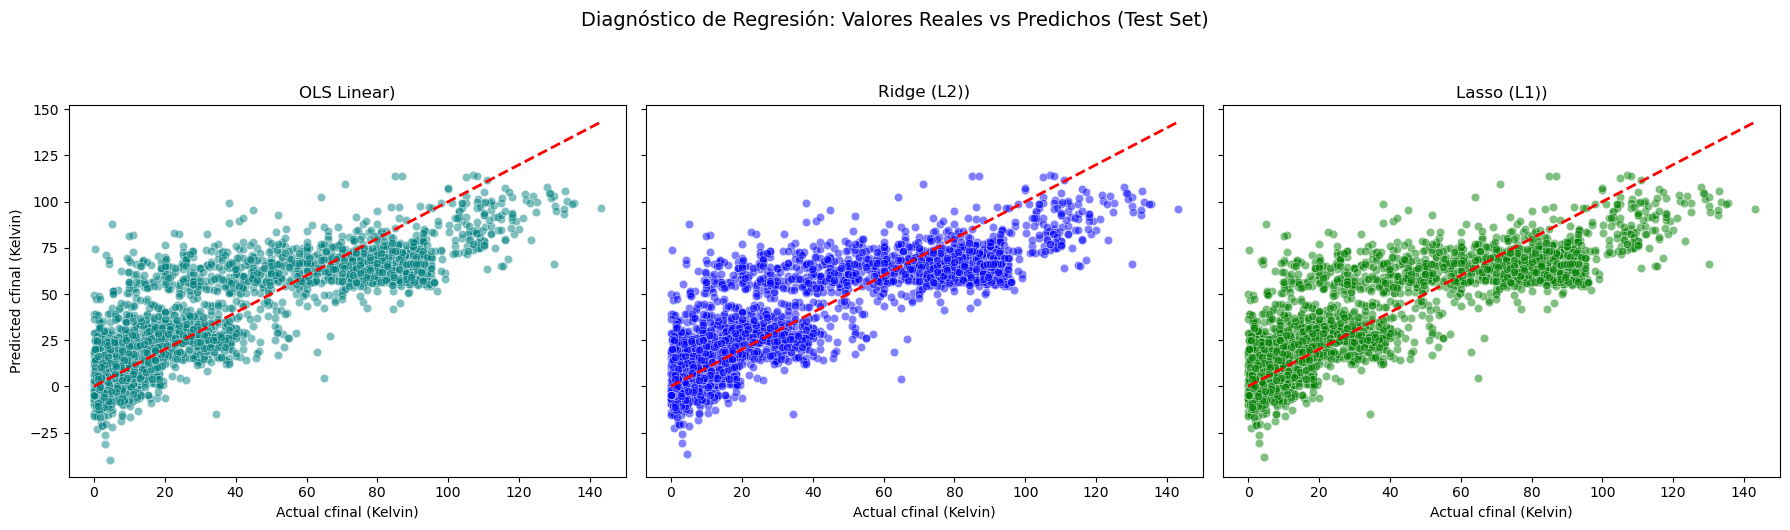

In [34]:
f.simple_testing(u_model, X_test_scaled, Y_test, color_used='teal')
f.simple_testing(r_model, X_test_scaled, Y_test, color_used='blue')
f.simple_testing(l_model, X_test_scaled, Y_test, color_used='green')
models = {'OLS Linear': u_model, 'Ridge (L2)': r_model, 'Lasso (L1)': l_model}
f.multiple_model_diagnostics(models, X_test_scaled, Y_test)


--- Procesando archivo de evaluación real ---


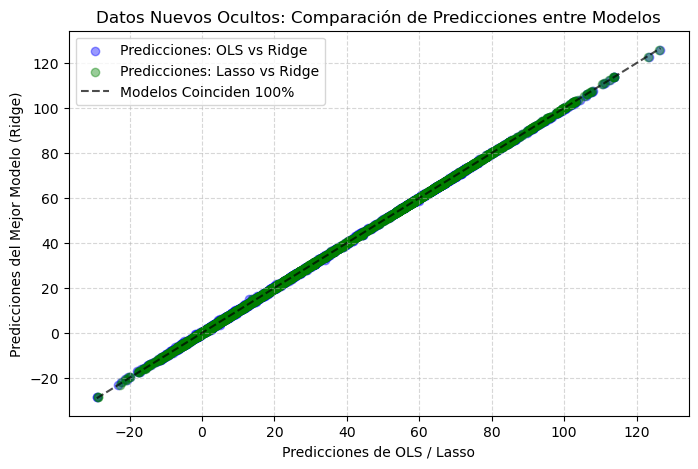

In [35]:
print("\n--- Procesando archivo de evaluación real ---")
eval_df = pd.read_csv('./data/evaluation_features.csv')
# Filtramos y escalamos usando estrictamente la misma estructura
X_eval_filtered = eval_df[features_to_use]
X_eval_scaled = scaler_final.transform(X_eval_filtered) # ¡Aquí ya no habrá ValueError!
# Generamos las predicciones para los datos nuevos ocultos
eval_preds_ols = u_model.predict(X_eval_scaled)
eval_preds_ridge = r_model.predict(X_eval_scaled)
eval_preds_lasso = l_model.predict(X_eval_scaled)

# =====================================================================
# GRÁFICO 2: COMPARACIÓN DE PREDICCIONES EN LOS DATOS NUEVOS
# =====================================================================
# Como no conocemos el valor real, comparamos los modelos entre sí en los datos nuevos
plt.figure(figsize=(8, 5))
plt.scatter(eval_preds_ols, eval_preds_ridge, alpha=0.4, label='Predicciones: OLS vs Ridge', color='blue')
plt.scatter(eval_preds_lasso, eval_preds_ridge, alpha=0.4, label='Predicciones: Lasso vs Ridge', color='green')

# Línea de concordancia perfecta entre modelos
min_val = min(eval_preds_ridge.min(), eval_preds_ols.min())
max_val = max(eval_preds_ridge.max(), eval_preds_ols.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Modelos Coinciden 100%')

plt.title('Datos Nuevos Ocultos: Comparación de Predicciones entre Modelos')
plt.xlabel('Predicciones de OLS / Lasso')
plt.ylabel('Predicciones del Mejor Modelo (Ridge)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Part 4: Neural Networks
1. **Build a Neural Network:** Implement a feedforward Neural Network (Multi-Layer Perceptron) using `sklearn`, `PyTorch`, or `Keras`.
2. **Cross-Validation/Tuning:** Experiment with the architecture (number of hidden layers, neurons) and learning rate. Use a validation set to prevent overfitting (Early Stopping is highly recommended).
3. **Evaluation:** Evaluate your best Neural Network on your local test set using the same metrics as the linear models (RMSE, MAE, $R^2$). 
4. **Reflection:** Plot the residuals (predicted vs. true values) for both your best Linear model and your Neural Network. In what range does the linear model struggle the most compared to the NN?
5. **Include your best nn weights in the submission using `joblib`**. Describe the arquitecture.

# Part 5: Final Analysis and Exporting Predictions

**Final Analysis:**
Which model performed the best on your local test set? If a physicist asked you *which features* are most important for discovering a new material with this data, which model would you show them and why? Explain the trade-off between interpretability and performance in this context.

**Generate Final Predictions:**
Use your **best overall model** to predict the critical temperatures for the materials in `evaluation_features.csv`. Export your predictions to a CSV file named `my_predictions.csv`. It is just one column. Call it `predicted_cfinal`. 

# Bonus
If you first perform PCA, can you accomplish any dimensionality reduction? are your predictions better? analyze and support your claims.  